# 3D plot to visulize 2D error in gantry system

In [127]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [128]:
folder_path = r"C:\Users\mj.j\Documents\2025_07_29_15_15_55"

In [129]:
# load log date
log_file_name = "Log_file_2D_expansion_X_axis.csv"
# get the log file inside the folder full file path
log_file_path = os.path.join(folder_path, log_file_name)
print(log_file_path)

# check the file is avelible at the location 

if os.path.exists(log_file_path):
    print("Log file found.")
    df = pd.read_csv(log_file_path)
    # Convert the DataFrame to a NumPy array
    log_data_array = df.to_numpy()
    print(log_data_array)
else:
    print("Log file not found.")

C:\Users\mj.j\Documents\2025_07_29_15_15_55\Log_file_2D_expansion_X_axis.csv
Log file found.
[['2025-07-29-15-16-01' 0 '0.png' ... 28.9 28.1 27.7]
 ['2025-07-29-15-16-06' 0 '1.png' ... 28.9 28.1 27.7]
 ['2025-07-29-15-16-12' 0 '2.png' ... 28.9 28.1 27.7]
 ...
 ['2025-07-29-15-43-27' 0 '297.png' ... 29.0 28.2 27.7]
 ['2025-07-29-15-43-33' 0 '298.png' ... 29.0 28.2 27.7]
 ['2025-07-29-15-43-38' 0 '299.png' ... 29.0 28.2 27.7]]


# Step 1 : Plot the differance bitween calculated position and mesured encoder position

In [ ]:
# load dot location matrix function
def open_3D_location_file(file_location,number_of_axis):
    array_2d = np.loadtxt(file_location, delimiter=',')
    rows_in_file,column = array_2d.shape
    calibration_data_table_row = rows_in_file//number_of_axis
    calibration_data_table_column = column
    position_np_array = np.zeros((number_of_axis,calibration_data_table_row,calibration_data_table_column))
    position_np_array = array_2d.reshape(number_of_axis,calibration_data_table_row,calibration_data_table_column)
    return position_np_array


# calculated locations file path 
calculated_dot_center_locations_file_name = "calculated_all_referance_locations.csv"
dot_center_location_file_path = os.path.join(folder_path, calculated_dot_center_locations_file_name)

# load calculated locations
number_of_axis = 3
calculated_location_numpy = open_3D_location_file(dot_center_location_file_path,number_of_axis)

# print shape
print(calculated_location_numpy.shape)



(3, 151, 151)


In [131]:
# load actual dot locations
actual_dot_locations_file_name = "Expansion_array_2D_0.csv"
actual_dot_locations_file_name = os.path.join(folder_path, actual_dot_locations_file_name)

number_of_axis = 3
actual_location_numpy = open_3D_location_file(actual_dot_locations_file_name,number_of_axis)

(1050,)


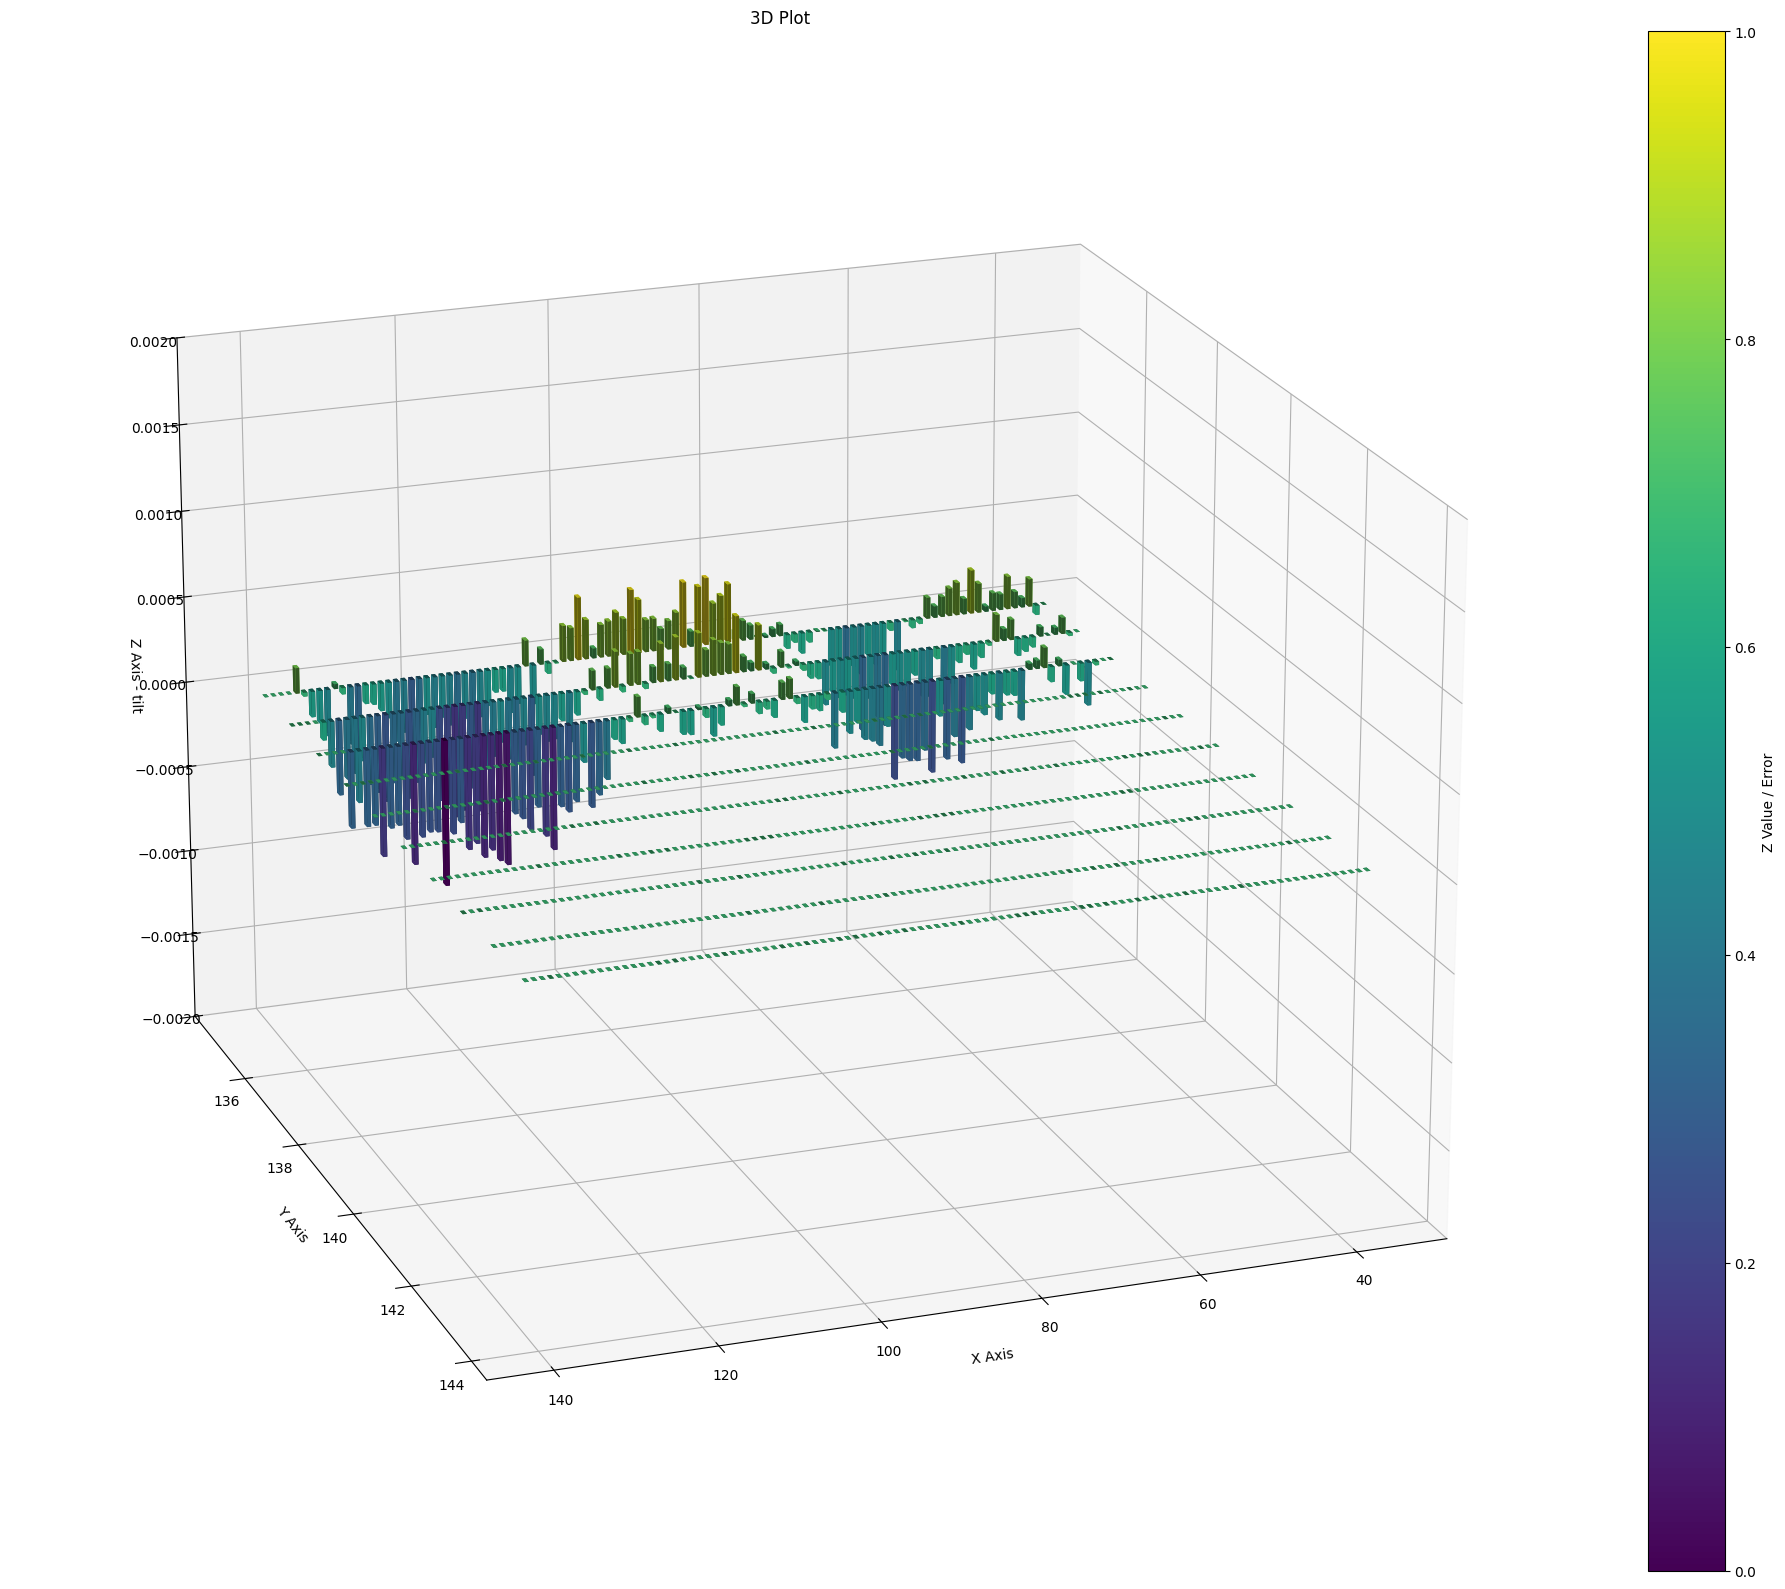

In [132]:
def plot_error_value(angle):

    # 3D plot of X, Y location and Z as position error 

    # Assuming 'calculated_location_numpy' has shape (3, rows, cols)
    # where axis 0 is for X, Y, and Z coordinates respectively.
    x_coords = calculated_location_numpy[0, :10, :105].flatten() # calculated X locations
    y_coords = calculated_location_numpy[1, :10, :105].flatten() # calculated Y locations
    z_coords = calculated_location_numpy[2, :10, :105].flatten() # This could be your glass scale tilt with respect to gantry 
    print(z_coords.shape)
    # make all the values in Z axis zeros
    z_coords = np.zeros_like(z_coords)  # perfect X and Y locations

    position_difference = actual_location_numpy[0,:10,:105] - calculated_location_numpy[0, :10, :105]
    position_difference = position_difference.flatten()

    # Create a new figure for the 3D plot
    fig = plt.figure(figsize=(20, 16))
    ax = fig.add_subplot(111, projection='3d')

    # Create the 3D scatter plot
    #scatter = ax.scatter(x_coords, y_coords, z_coords, marker='.')
    #scatter = ax.scatter(x_coords, y_coords, z_coords, c=position_difference, cmap='viridis', marker='.')
    #scatter = ax.scatter(x_coords, y_coords, z_coords, c=z_coords, cmap='viridis', marker='o')

    # Get a colormap
    cmap = plt.get_cmap('viridis')
    # Normalize the position_difference values to the range [0, 1]
    norm = plt.Normalize(position_difference.min(), position_difference.max())
    # Map the normalized values to colors
    colors = cmap(norm(position_difference))


    dx = 0.5  # width of bars in x direction
    dy = 0.1  # depth of bars in y direction
    scatter = ax.bar3d(x_coords, y_coords, z_coords, dx, dy, position_difference, color=colors)

    # Set labels for the axes
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis - tilt')

    ax.set_zlim(-0.002, 0.002)

    # Set a title for the plot
    ax.set_title('3D Plot')

    # angle = -60

    ax.view_init(elev=20, azim=angle)

    # Add a color bar which maps values to colors
    fig.colorbar(scatter, ax=ax, label='Z Value / Error')

    # Show the plot
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, f"3D_plot_XY_error_{angle}.png"))
    plt.show()



for i in range(70, 71, 1):
    plot_error_value(i)
        


### Y axis error calculator

(1050,)


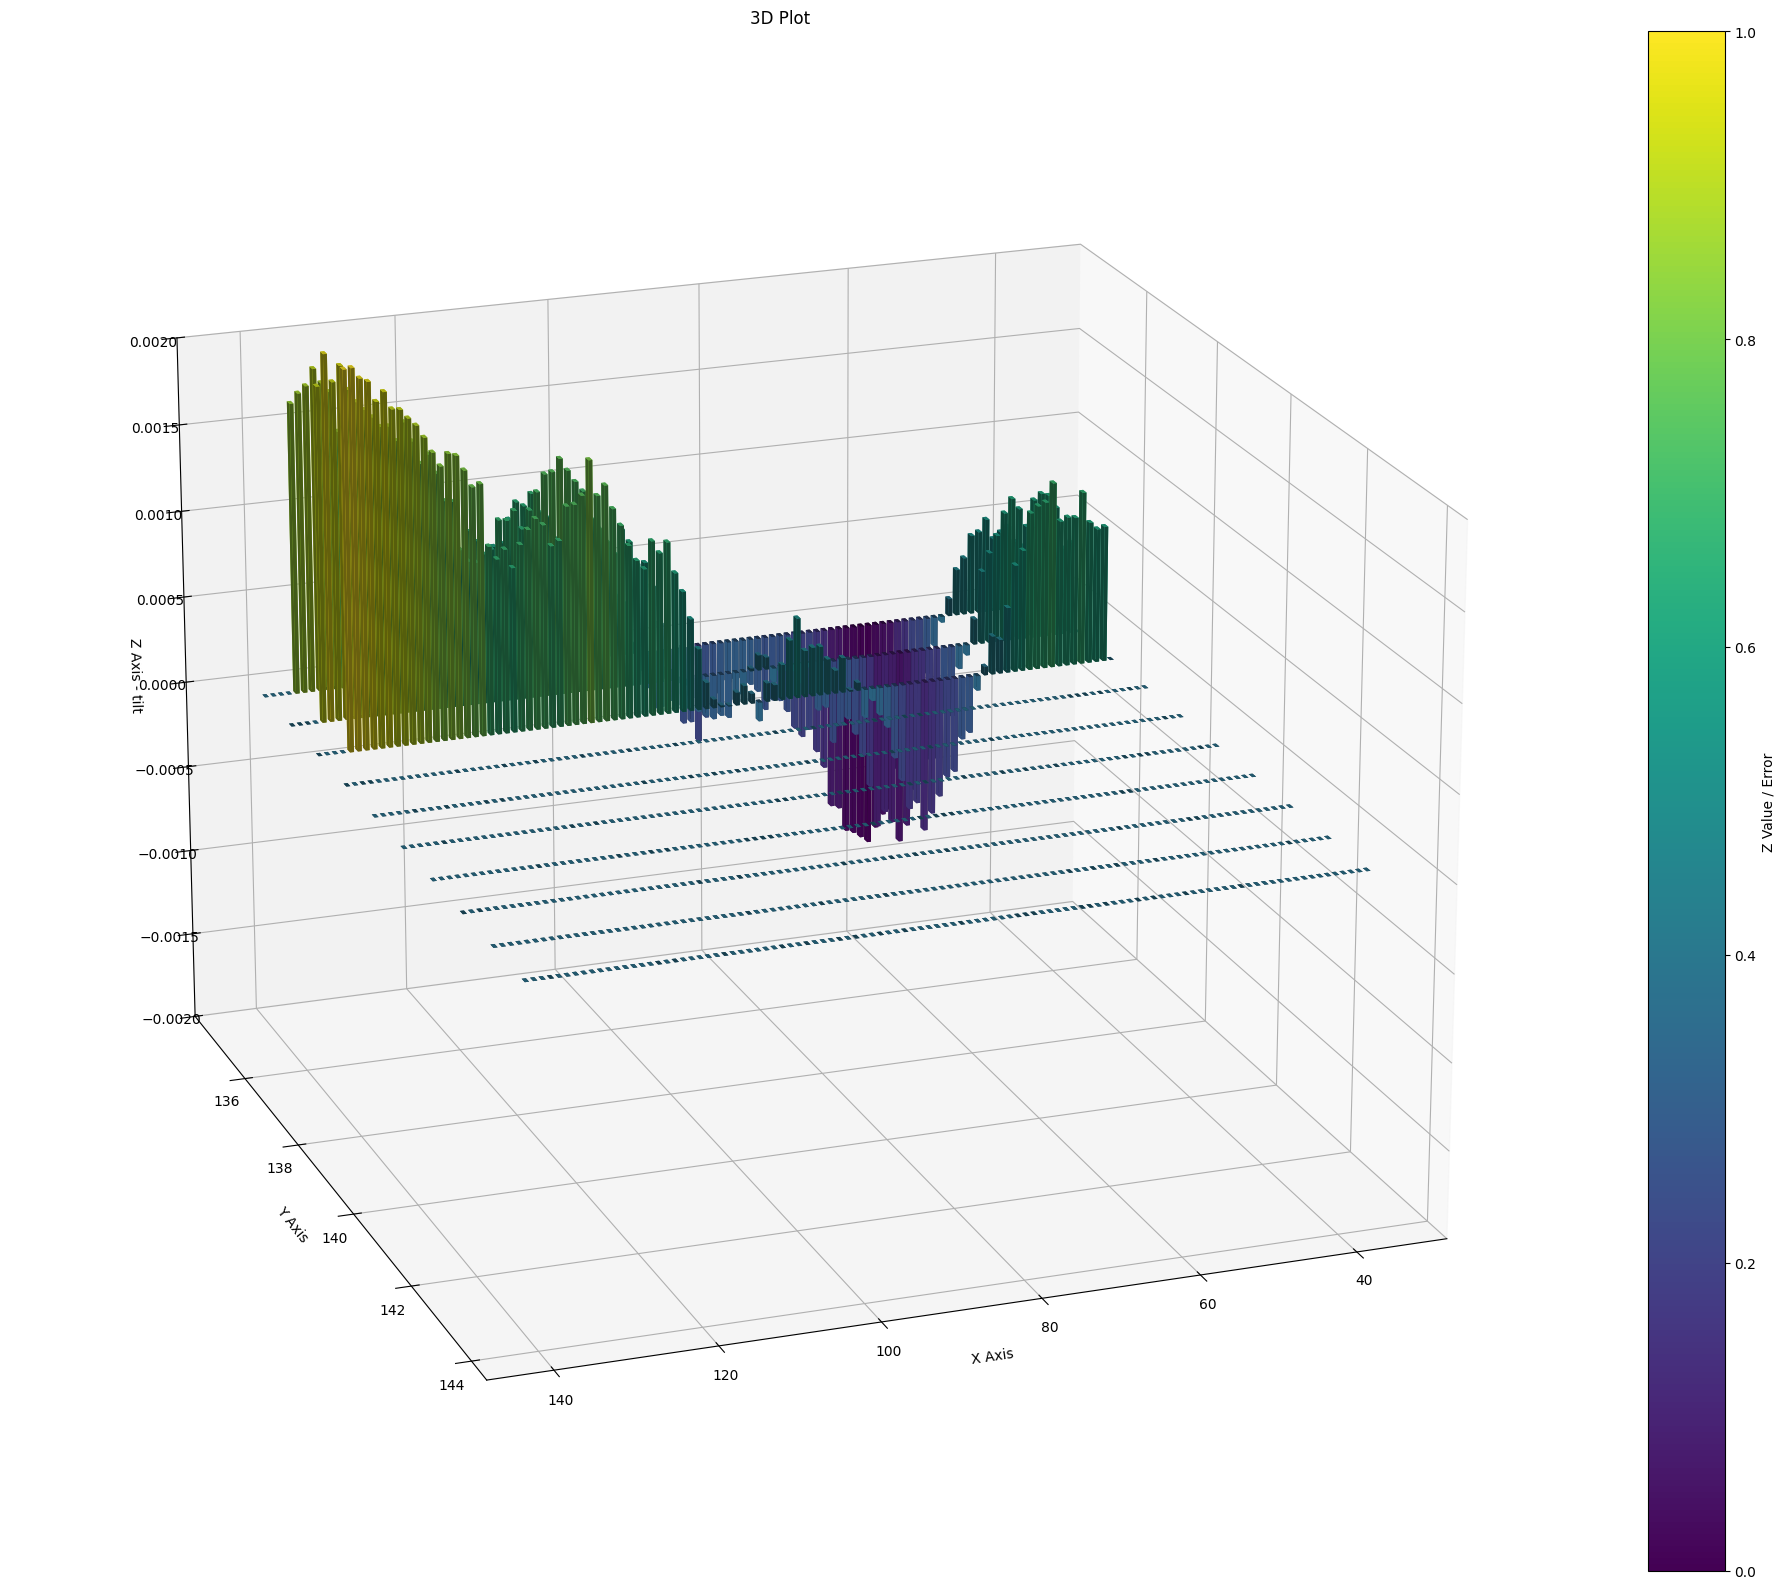

In [133]:
def plot_error_value(angle):

    # 3D plot of X, Y location and Z as position error 

    # Assuming 'calculated_location_numpy' has shape (3, rows, cols)
    # where axis 0 is for X, Y, and Z coordinates respectively.
    x_coords = calculated_location_numpy[0, :10, :105].flatten() # calculated X locations
    y_coords = calculated_location_numpy[1, :10, :105].flatten() # calculated Y locations
    z_coords = calculated_location_numpy[2, :10, :105].flatten() # This could be your glass scale tilt with respect to gantry 
    print(z_coords.shape)
    # make all the values in Z axis zeros
    z_coords = np.zeros_like(z_coords)  # perfect X and Y locations

    position_difference = actual_location_numpy[1,:10,:105] - calculated_location_numpy[1, :10, :105]
    position_difference = position_difference.flatten()

    # Create a new figure for the 3D plot
    fig = plt.figure(figsize=(20, 16))
    ax = fig.add_subplot(111, projection='3d')

    # Create the 3D scatter plot
    #scatter = ax.scatter(x_coords, y_coords, z_coords, marker='.')
    #scatter = ax.scatter(x_coords, y_coords, z_coords, c=position_difference, cmap='viridis', marker='.')
    #scatter = ax.scatter(x_coords, y_coords, z_coords, c=z_coords, cmap='viridis', marker='o')

    # Get a colormap
    cmap = plt.get_cmap('viridis')
    # Normalize the position_difference values to the range [0, 1]
    norm = plt.Normalize(position_difference.min(), position_difference.max())
    # Map the normalized values to colors
    colors = cmap(norm(position_difference))


    dx = 0.5  # width of bars in x direction
    dy = 0.1  # depth of bars in y direction
    scatter = ax.bar3d(x_coords, y_coords, z_coords, dx, dy, position_difference, color=colors)

    # Set labels for the axes
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis - tilt')

    ax.set_zlim(-0.002, 0.002)

    # Set a title for the plot
    ax.set_title('3D Plot')

    # angle = -60

    ax.view_init(elev=20, azim=angle)

    # Add a color bar which maps values to colors
    fig.colorbar(scatter, ax=ax, label='Z Value / Error')

    # Show the plot
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, f"3D_plot_XY_error_{angle}.png"))
    plt.show()



for i in range(70, 71, 1):
    plot_error_value(i)

In [121]:
# Step 1 : Plot the difference between calculated position and measured encoder position

# Step 2 : Plot the difference between calculated position and vision mesured position

In [134]:
# get calculated location
calculated_location_numpy = open_3D_location_file(dot_center_location_file_path,number_of_axis)

# print shape
print(calculated_location_numpy[0, :5, :5])
print("---")
print(calculated_location_numpy[1, :5, :5])
print("---")
print(calculated_location_numpy[2, :5, :5])


[[35.977871 36.977749 37.977628 38.977506 39.977385]
 [35.977802 36.977681 37.977559 38.977437 39.977316]
 [35.977733 36.977612 37.97749  38.977368 39.977247]
 [35.977664 36.977543 37.977421 38.9773   39.977178]
 [35.977595 36.977474 37.977352 38.977231 39.977109]]
---
[[134.71748  134.717575 134.71767  134.717766 134.717861]
 [135.717524 135.717619 135.717715 135.71781  135.717905]
 [136.717568 136.717663 136.717759 136.717854 136.717949]
 [137.717612 137.717708 137.717803 137.717898 137.717993]
 [138.717657 138.717752 138.717847 138.717942 138.718037]]
---
[[21.7997   21.798369 21.797037 21.795706 21.794375]
 [21.7997   21.798369 21.797037 21.795706 21.794375]
 [21.7997   21.798369 21.797037 21.795706 21.794375]
 [21.7997   21.798369 21.797037 21.795706 21.794375]
 [21.7997   21.798369 21.797037 21.795706 21.794375]]


(3, 151, 151)
---
(3, 151, 151)
---
[[ 0.        0.        0.999888  1.999643  2.99946 ]
 [ 0.       -0.011872  0.987976  1.987765  2.987593]
 [ 0.        0.        0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.      ]]
---
[[ 0.        0.       -0.000324 -0.000556 -0.000833]
 [ 0.        0.999374  0.999023  0.998803  0.998502]
 [ 0.        0.        0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.      ]]
---
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [144]:
np.set_printoptions(suppress=True, precision=6)

calculated_location_numpy[0, :10, :100] = calculated_location_numpy[0, :10, :100] - calculated_location_numpy[0, 0, 1]
calculated_location_numpy[0, 2:, :] = 0
position_difference_vision = calculated_location_numpy[0, :10, :100] - vision_rotation_matrix_numpy[0, :10, :100]
position_difference_vision[1, :] = position_difference_vision[1, :] - position_difference_vision[1,1]
position_difference_vision[:, 0] = 0

print(calculated_location_numpy[0, :10, :10])

print("---")
print(vision_rotation_matrix_numpy.shape)
print(vision_rotation_matrix_numpy[0, :10, :10])

print("---")
print(position_difference_vision[:2, :60])






[[-0.999878  0.        0.999879  1.999757  2.999636  3.999514  4.999393
   5.999271  6.999149  7.999028]
 [-0.999947 -0.000068  0.99981   1.999688  2.999567  3.999445  4.999324
   5.999202  6.99908   7.998959]
 [ 0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.      

In [151]:
# folder path
folder_path = r"C:\Users\mj.j\Documents\2025_07_29_15_15_55"

# calculated locations file path
calculated_dot_center_locations_file_name = "calculated_all_referance_locations.csv"
dot_center_location_file_path = os.path.join(folder_path, calculated_dot_center_locations_file_name)

# load calculated locations
number_of_axis = 3
calculated_location_numpy = open_3D_location_file(dot_center_location_file_path,number_of_axis)

# print shape
print(calculated_location_numpy.shape)
print("---")

# vision rotation matrix file path
vision_rotation_matrix_file_path = "vision_rotation_matrix.csv"
vision_rotation_matrix_full_file_path = os.path.join(folder_path, vision_rotation_matrix_file_path)

# load vision rotation matrix
number_of_axis = 3
vision_rotation_matrix_numpy = open_3D_location_file(vision_rotation_matrix_full_file_path, number_of_axis)

print(vision_rotation_matrix_numpy.shape)
print("---")
print(vision_rotation_matrix_numpy[0, :5, :5])
print("---")
print(vision_rotation_matrix_numpy[1, :5, :5])
print("---")
print(vision_rotation_matrix_numpy[2, :5, :5])

(3, 151, 151)
---
(3, 151, 151)
---
[[ 0.        0.        0.999888  1.999643  2.99946 ]
 [ 0.       -0.011872  0.987976  1.987765  2.987593]
 [ 0.        0.        0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.      ]]
---
[[ 0.        0.       -0.000324 -0.000556 -0.000833]
 [ 0.        0.999374  0.999023  0.998803  0.998502]
 [ 0.        0.        0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.      ]]
---
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


(1000,)


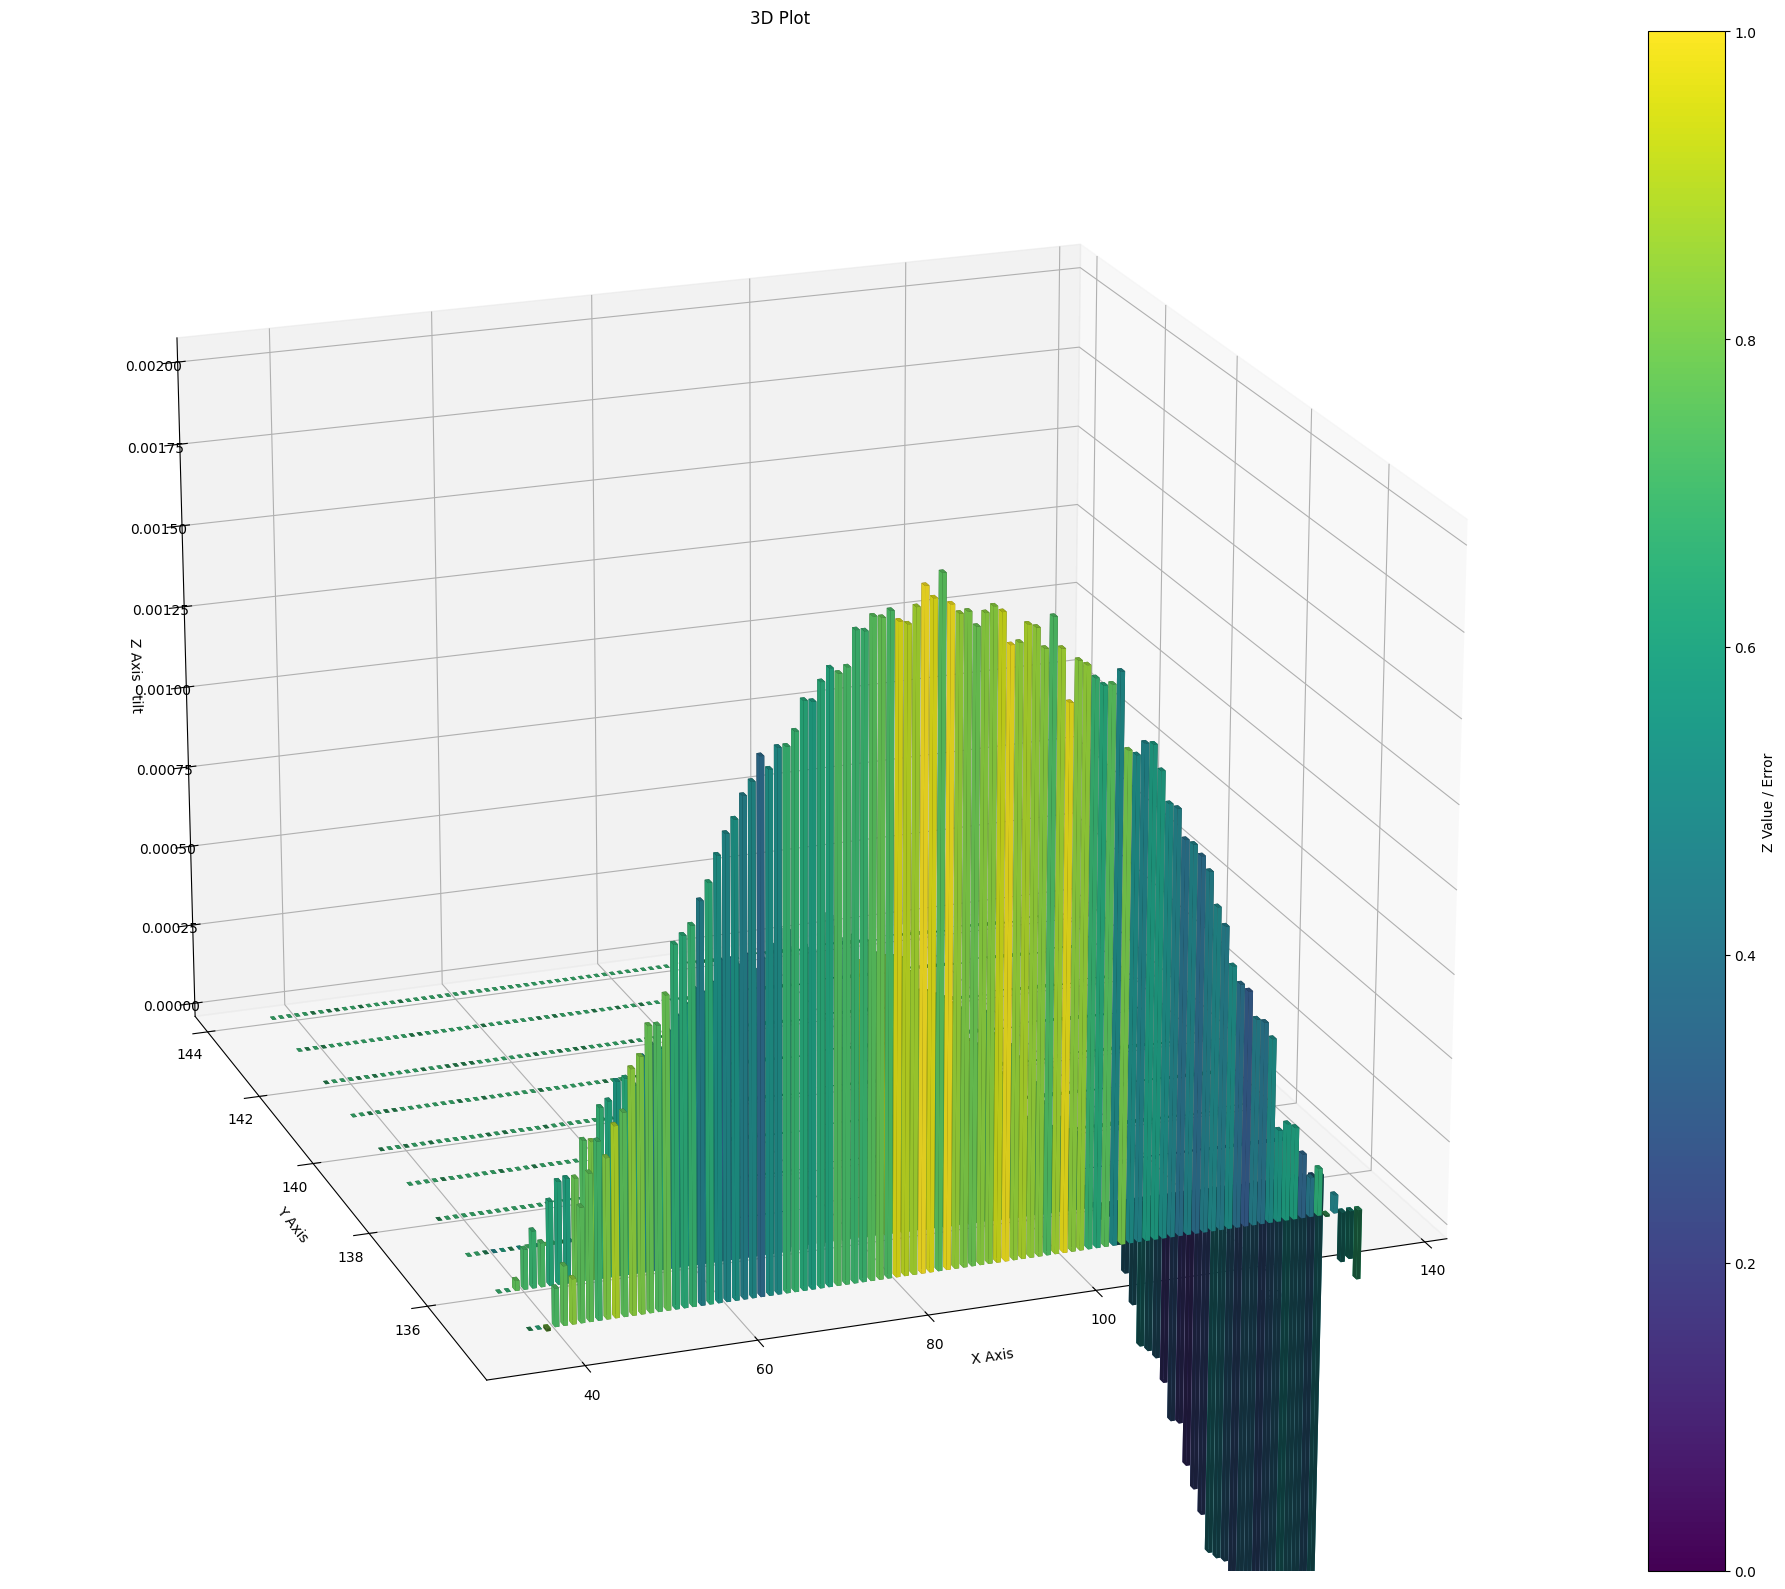

In [152]:
def plot_error_value(angle):

    # 3D plot of X, Y location and Z as position error 

    # Assuming 'calculated_location_numpy' has shape (3, rows, cols)
    # where axis 0 is for X, Y, and Z coordinates respectively.
    x_coords = calculated_location_numpy[0, :10, :100].flatten() # calculated X locations
    y_coords = calculated_location_numpy[1, :10, :100].flatten() # calculated Y locations
    z_coords = calculated_location_numpy[2, :10, :100].flatten() # This could be your glass scale tilt with respect to gantry 
    print(z_coords.shape)
    # make all the values in Z axis zeros
    z_coords = np.zeros_like(z_coords)  # perfect X and Y locations

    position_difference = actual_location_numpy[0,:10,:100] - calculated_location_numpy[0, :10, :100]
    position_difference = position_difference.flatten()

    calculated_location_numpy[0, :10, :100] = calculated_location_numpy[0, :10, :100] - calculated_location_numpy[0, 0, 1]
    calculated_location_numpy[0, 2:, :] = 0
    position_difference_vision = calculated_location_numpy[0, :10, :100] - vision_rotation_matrix_numpy[0, :10, :100]
    position_difference_vision[1, :] = position_difference_vision[1, :] - position_difference_vision[1,1]
    position_difference_vision[:, 0] = 0
    
    position_difference_vision = position_difference_vision.flatten()

    # Create a new figure for the 3D plot
    fig = plt.figure(figsize=(20, 16))
    ax = fig.add_subplot(111, projection='3d')

    # Create the 3D scatter plot
    # scatter = ax.scatter(x_coords, y_coords, z_coords, marker='.')
    # scatter = ax.scatter(x_coords, y_coords, z_coords, c=position_difference, cmap='viridis', marker='.')
    # scatter = ax.scatter(x_coords, y_coords, z_coords, c=z_coords, cmap='viridis', marker='o')

    # Get a colormap
    cmap = plt.get_cmap('viridis')
    # Normalize the position_difference values to the range [0, 1]
    norm = plt.Normalize(position_difference.min(), position_difference.max())
    # Map the normalized values to colors
    colors = cmap(norm(position_difference))

    dx = 0.5  # width of bars in x direction
    dy = 0.1  # depth of bars in y direction
    #scatter = ax.bar3d(x_coords, y_coords, z_coords, dx, dy, z_coords, color=colors)
    scatter = ax.bar3d(x_coords, y_coords, z_coords, dx, dy, position_difference_vision, color=colors)

    # Set labels for the axes
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis - tilt')

    #ax.set_zlim(-0.002, 0.002)

    # Set a title for the plot
    ax.set_title('3D Plot')

    # angle = -60

    ax.view_init(elev=20, azim=angle)

    # Add a color bar which maps values to colors
    fig.colorbar(scatter, ax=ax, label='Z Value / Error')

    # Show the plot
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, f"3D_plot_XY_error_{angle}.png"))
    plt.show()



for i in range(250, 251, 1):
    plot_error_value(i)
        
